In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import torch as torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


In [44]:
def show_game_state(game_state):
    assert len(game_state) == 9, "Game state must have exactly 9 elements."
    print(f"\t | 1 \t| 2 \t| 3")
    print(f"---------------------------------")
    print(f"A \t| {game_state[0]} \t| {game_state[1]} \t| {game_state[2]}")
    print(f"---------------------------------")
    print(f"B \t| {game_state[3]} \t| {game_state[4]} \t| {game_state[5]}")
    print(f"---------------------------------")
    print(f"C \t| {game_state[6]} \t| {game_state[7]} \t| {game_state[8]}")
    print(f"---------------------------------")

def is_game_over(game_state):
    assert len(game_state) == 9, "Game state must have exactly 9 elements."
    game_state_2d = game_state.reshape(3, 3)
    # numbers = +1 or -1 for players, 0 for empty

    row_sums = game_state_2d.sum(axis=1)
    col_sums = game_state_2d.sum(axis=0)
    diag1_sum = game_state_2d.trace()
    game_state_flipped = np.fliplr(game_state_2d)
    diag2_sum = game_state_flipped.trace()
    winning_sums = [3, -3]
    all_sums = list(row_sums) + list(col_sums) + [diag1_sum, diag2_sum]
    for s in all_sums:
        if s in winning_sums:
            return True, s
    
    unique, counts = np.unique(game_state, return_counts=True)
    if 0 not in unique:
        return True, 0

    return False, 0

def run_random_game(verbose=False):
    game_state = np.zeros(9, dtype=int)
    current_player = np.random.choice([-1, 1])
    first_player = current_player.copy()
    opponent = -current_player
    game_over = False
    all_user_inputs = [(game_state.copy(), 0, -1)]  # Initial state with no move
    while not game_over:
        available_moves = np.where(game_state == 0)[0]
        chosen_move = np.random.choice(available_moves)
        all_user_inputs.append((game_state.copy(), current_player, chosen_move))
        game_state[chosen_move] = current_player
        game_over, result = is_game_over(game_state)
        if game_over:
            if verbose:
                show_game_state(game_state)
            if result == 3:
                if verbose:
                    print("Player 1 wins!")
            elif result == -3:
                if verbose:
                    print("Player 2 wins!")
            else:
                if verbose:
                    print("It's a draw!")
            who_won = 1 if result == 3 else (-1 if result == -3 else 0)
            first_player_won = True if who_won == first_player else False
            return who_won, all_user_inputs, first_player_won
        
        current_player, opponent = opponent, current_player

def minimax_tictactoe(game_state):
    """
    Minimax algorithm for tic-tac-toe.
    
    Args:
        game_state: numpy array of size 9
                   +1 = user (maximizer)
                   -1 = AI/minimax (minimizer)
                    0 = empty
    
    Returns:
        best_move: index (0-8) of the best move for the current player
    """
    
    def check_winner(state):
        """Check if there's a winner. Returns +1, -1, or 0."""
        # Reshape to 3x3 for easier checking
        board = state.reshape(3, 3)
        
        # Check rows
        for row in board:
            if abs(sum(row)) == 3:
                return row[0]
        
        # Check columns
        for col in range(3):
            col_sum = sum(board[:, col])
            if abs(col_sum) == 3:
                return board[0, col]
        
        # Check diagonals
        diag1 = board[0, 0] + board[1, 1] + board[2, 2]
        if abs(diag1) == 3:
            return board[1, 1]
        
        diag2 = board[0, 2] + board[1, 1] + board[2, 0]
        if abs(diag2) == 3:
            return board[1, 1]
        
        return 0
    
    def is_terminal(state):
        """Check if game is over."""
        return check_winner(state) != 0 or 0 not in state
    
    def minimax(state, is_maximizing):
        """Recursive minimax function."""
        winner = check_winner(state)
        
        # Terminal states
        if winner == 1:
            return 10  # User wins
        elif winner == -1:
            return -10  # AI wins
        elif 0 not in state:
            return 0  # Draw
        
        if is_maximizing:
            # User's turn (maximizer)
            max_eval = -np.inf
            for i in range(9):
                if state[i] == 0:
                    state[i] = 1
                    eval_score = minimax(state, False)
                    state[i] = 0
                    max_eval = max(max_eval, eval_score)
            return max_eval
        else:
            # AI's turn (minimizer)
            min_eval = np.inf
            for i in range(9):
                if state[i] == 0:
                    state[i] = -1
                    eval_score = minimax(state, True)
                    state[i] = 0
                    min_eval = min(min_eval, eval_score)
            return min_eval
    
    # Determine whose turn it is based on piece count
    count_user = np.sum(game_state == 1)
    count_ai = np.sum(game_state == -1)
    is_ai_turn = count_user > count_ai
    
    # Find best move
    best_move = -1
    best_value = np.inf if is_ai_turn else -np.inf
    
    for i in range(9):
        if game_state[i] == 0:
            # Try this move
            game_state[i] = -1 if is_ai_turn else 1
            move_value = minimax(game_state, not is_ai_turn)
            game_state[i] = 0
            
            # Update best move
            if is_ai_turn:
                if move_value < best_value:
                    best_value = move_value
                    best_move = i
            else:
                if move_value > best_value:
                    best_value = move_value
                    best_move = i
    
    return best_move

def minimax_lookup(game_state):
    """
    Precomputed minimax optimal moves.
    This is the actual minimax solution encoded as rules.
    """
    
    def check_win_or_block(state, player):
        lines = [[0,1,2],[3,4,5],[6,7,8],[0,3,6],[1,4,7],[2,5,8],[0,4,8],[2,4,6]]
        for line in lines:
            vals = [state[i] for i in line]
            if vals.count(player) == 2 and vals.count(0) == 1:
                return line[vals.index(0)]
        return None
    
    # Win or block
    for player in [-1, 1]:
        move = check_win_or_block(game_state, player)
        if move is not None:
            return move
    
    # Optimal opening moves (first move)
    if np.sum(game_state != 0) == 0:
        return 0  # Corner
    
    # Response to first move
    if np.sum(game_state != 0) == 1:
        if game_state[4] == 1:  # Opponent took center
            return 0  # Take corner
        else:
            return 4  # Take center
    
    # Center if available
    if game_state[4] == 0:
        return 4
    
    # Corners, prioritizing opposite corner
    corners = [0, 2, 6, 8]
    opp_corner = {0:8, 8:0, 2:6, 6:2}
    for c in corners:
        if game_state[c] == 1 and game_state[opp_corner[c]] == 0:
            return opp_corner[c]
    
    for c in corners:
        if game_state[c] == 0:
            return c
    
    # Edges
    for e in [1, 3, 5, 7]:
        if game_state[e] == 0:
            return e
    
    return None

def run_random_game_with_minimax(verbose=False):
    # minimax = -1 for AI, +1 for random computer player
    game_state = np.zeros(9, dtype=int)
    current_player = np.random.choice([-1, 1])
    first_player = current_player.copy()
    opponent = -current_player
    game_over = False
    all_user_inputs = [(game_state.copy(), 0, -1)]  # Initial state with no move
    while not game_over:
        available_moves = np.where(game_state == 0)[0]
        if current_player == -1:
            chosen_move = minimax_lookup(game_state)
        else:
            chosen_move = np.random.choice(available_moves)
        all_user_inputs.append((game_state.copy(), current_player, chosen_move))
        game_state[chosen_move] = current_player
        game_over, result = is_game_over(game_state)
        if game_over:
            if verbose:
                show_game_state(game_state)
            if result == 3:
                if verbose:
                    print("Player 1 wins!")
            elif result == -3:
                if verbose:
                    print("Player 2 wins!")
            else:
                if verbose:
                    print("It's a draw!")
            who_won = 1 if result == 3 else (-1 if result == -3 else 0)
            first_player_won = True if who_won == first_player else False
            return who_won, all_user_inputs, first_player_won
        
        current_player, opponent = opponent, current_player

def model_predict_next_move(game_state, model):
    model.eval()
    with torch.no_grad():
        input_tensor = torch.tensor(game_state, dtype=torch.float32).unsqueeze(0)
        output = model(input_tensor)
        predicted_move = torch.argmax(output, dim=1).item()
    return predicted_move

def run_random_game_with_model(model_input, verbose=False):
    # -1 for model, +1 for random computer player
    game_state = np.zeros(9, dtype=int)
    current_player = np.random.choice([-1, 1])
    first_player = current_player.copy()
    opponent = -current_player
    game_over = False
    all_user_inputs = [(game_state.copy(), 0, -1)]  # Initial state with no move
    while not game_over:
        available_moves = np.where(game_state == 0)[0]
        if current_player == -1:
            chosen_move = model_predict_next_move(game_state, model_input)
        else:
            chosen_move = np.random.choice(available_moves)
        all_user_inputs.append((game_state.copy(), current_player, chosen_move))
        game_state[chosen_move] = current_player
        game_over, result = is_game_over(game_state)
        if game_over:
            if verbose:
                show_game_state(game_state)
            if result == 3:
                if verbose:
                    print("Player 1 wins!")
            elif result == -3:
                if verbose:
                    print("Player 2 wins!")
            else:
                if verbose:
                    print("It's a draw!")
            who_won = 1 if result == 3 else (-1 if result == -3 else 0)
            first_player_won = True if who_won == first_player else False
            return who_won, all_user_inputs, first_player_won
        
        current_player, opponent = opponent, current_player

def run_models_against_each_other(model_1, model_2, verbose=False):
    # -1 for model, +1 for random computer player
    from time import sleep
    from IPython.display import clear_output
    game_state = np.zeros(9, dtype=int)
    current_player = np.random.choice([-1, 1])
    first_player = current_player.copy()
    opponent = -current_player
    game_over = False
    all_user_inputs = [(game_state.copy(), 0, -1)]  # Initial state with no move
    while not game_over:
        available_moves = np.where(game_state == 0)[0]
        #show_game_state(game_state)
        if current_player == 1:
            decision_made_by_player_1 = False
            while not decision_made_by_player_1:
                chosen_move = model_predict_next_move(game_state, model_1)
                decision_made_by_player_1 = chosen_move in available_moves
                if not decision_made_by_player_1:
                    print(f"Model 1 predicted invalid move {chosen_move}. Retrying...")
        else:
            decision_made_by_player_2 = False
            while not decision_made_by_player_2:
                chosen_move = model_predict_next_move(game_state, model_2)
                decision_made_by_player_2 = chosen_move in available_moves
                if not decision_made_by_player_2:
                    print(f"Model 2 predicted invalid move {chosen_move}. Retrying...")

        all_user_inputs.append((game_state.copy(), current_player, chosen_move))
        game_state[chosen_move] = current_player
        #sleep(1)
        clear_output(wait=True)
        game_over, result = is_game_over(game_state)
        if game_over:
            if verbose:
                show_game_state(game_state)
            if result == 3:
                if verbose:
                    print("Player 1 wins!")
            elif result == -3:
                if verbose:
                    print("Player 2 wins!")
            else:
                if verbose:
                    print("It's a draw!")
            who_won = 1 if result == 3 else (-1 if result == -3 else 0)
            first_player_won = True if who_won == first_player else False
            #show_game_state(game_state)
            return who_won, all_user_inputs, first_player_won
        
        current_player, opponent = opponent, current_player

def run_models_against_minimax(model_input, verbose=False):
    # -1 for model, +1 for random computer player
    game_state = np.zeros(9, dtype=int)
    current_player = np.random.choice([-1, 1])
    first_player = current_player.copy()
    opponent = -current_player
    game_over = False
    all_user_inputs = [(game_state.copy(), 0, -1)]  # Initial state with no move
    while not game_over:
        available_moves = np.where(game_state == 0)[0]
        if current_player == -1:
            chosen_move = model_predict_next_move(game_state, model_input)
        else:
            chosen_move = minimax_lookup(game_state)
        all_user_inputs.append((game_state.copy(), current_player, chosen_move))
        game_state[chosen_move] = current_player
        game_over, result = is_game_over(game_state)
        if game_over:
            if verbose:
                show_game_state(game_state)
            if result == 3:
                if verbose:
                    print("Player 1 wins!")
            elif result == -3:
                if verbose:
                    print("Player 2 wins!")
            else:
                if verbose:
                    print("It's a draw!")
            who_won = 1 if result == 3 else (-1 if result == -3 else 0)
            first_player_won = True if who_won == first_player else False
            return who_won, all_user_inputs, first_player_won
        
        current_player, opponent = opponent, current_player


In [3]:
# Step 1: Learn legal moves
from tqdm import tqdm

list_of_who_won_random = []
list_of_next_moves_random = []
for i in tqdm(range(2000), desc="Simulating random games"):
    who_won, all_user_inputs, first_player_won = run_random_game(verbose=False)
    list_of_who_won_random.append(who_won)
    list_of_next_moves_random.append([(x[0], x[2]) for x in all_user_inputs[1:]])  # Store only game states

list_of_who_won_minimax = []
list_of_next_moves_minimax = []
for i in tqdm(range(1000), desc="Simulating random games with minimax opponent"):
    who_won, all_user_inputs, first_player_won = run_random_game_with_minimax(verbose=False)
    list_of_who_won_minimax.append(who_won)
    list_of_next_moves_minimax.append([(x[0], x[2]) for x in all_user_inputs[1:]])  # Store only game states



Simulating random games with minimax opponent: 100%|██████████| 1000/1000 [00:00<00:00, 5187.91it/s]


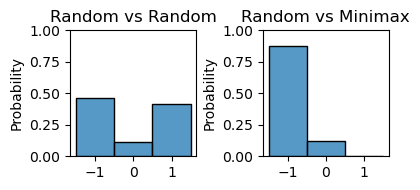

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(4, 2))
sns.histplot(list_of_who_won_random, discrete=True, stat="probability", ax=axs[0])
axs[0].set_title("Random vs Random")
axs[0].set_ylim(0, 1)
sns.histplot(list_of_who_won_minimax, discrete=True, stat="probability", ax=axs[1])
axs[1].set_title("Random vs Minimax")
axs[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [5]:
import torch
import torch.nn as nn

device = torch.device("cpu")

class LegalMovesModel(nn.Module):
    def __init__(self):
        super(LegalMovesModel, self).__init__()
        self.fc1 = nn.Linear(9, 81)
        self.fc2b = nn.Linear(81, 81)
        self.fc3 = nn.Linear(81, 9)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
        self.dropout = nn.Dropout(p=0.2)
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        #x = self.relu(self.fc2(x))
        #x = self.dropout(x)
        #x = self.relu(self.fc2a(x))
        #x = self.dropout(x)
        x = self.relu(self.fc2b(x))
        x = self.dropout(x)
        x = self.fc3(x)
        x = self.softmax(x)
        return x





In [6]:
def train_model(model, criterion, optimizer, num_epochs, list_of_next_moves, batch_size):
    # Create training data generator
    x_input_list = []
    y_output_list = []
    for game in list_of_next_moves:
        for step in game:
            x_input = step[0]
            y_output = step[1]
            x_input_list.append(x_input)
            y_output_list.append(y_output)


    x_input_tensor = torch.tensor(np.array(x_input_list), dtype=torch.float32).to(device)
    y_output_tensor = torch.tensor(np.array(y_output_list), dtype=torch.long).to(device)


    # create dataset and dataloader
    from torch.utils.data import TensorDataset, DataLoader
    dataset = TensorDataset(x_input_tensor, y_output_tensor)

    # split data into training and validation sets
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)    

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        
        epoch_loss = running_loss / len(dataset)
        running_val_loss = 0.0
        for inputs, labels in val_loader:
            model.eval()
            with torch.no_grad():
                outputs = model(inputs)
                val_loss = criterion(outputs, labels)
                running_val_loss += val_loss.item() * inputs.size(0)
        epoch_val_loss = running_val_loss / len(val_dataset)

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")
    return model


In [36]:
model_minimax = LegalMovesModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_minimax.parameters(), lr=0.001, weight_decay=1e-5)
num_epochs = 10

model_minimax = train_model(model_minimax, criterion, optimizer, num_epochs, list_of_next_moves_minimax, batch_size=64)

list_of_next_moves_random_1 = list_of_next_moves_random[:1000]
list_of_next_moves_random_2 = list_of_next_moves_random[1000:]

model_random_1 = LegalMovesModel().to(device)
num_epochs = 500
model_random_1 = train_model(model_random_1, criterion, optimizer, num_epochs, list_of_next_moves_random_1, batch_size=64)

model_random_2 = LegalMovesModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_random_2.parameters(), lr=0.001, weight_decay=1e-5)
num_epochs = 500
model_random_2 = train_model(model_random_2, criterion, optimizer, num_epochs, list_of_next_moves_random_2, batch_size=64)




Epoch 1/10, Loss: 1.7427, Val Loss: 2.1263
Epoch 2/10, Loss: 1.6578, Val Loss: 2.0079
Epoch 3/10, Loss: 1.5990, Val Loss: 1.9568
Epoch 4/10, Loss: 1.5618, Val Loss: 1.9325
Epoch 5/10, Loss: 1.5449, Val Loss: 1.9186
Epoch 6/10, Loss: 1.5352, Val Loss: 1.9130
Epoch 7/10, Loss: 1.5283, Val Loss: 1.9059
Epoch 8/10, Loss: 1.5214, Val Loss: 1.8936
Epoch 9/10, Loss: 1.5137, Val Loss: 1.8849
Epoch 10/10, Loss: 1.5064, Val Loss: 1.8751
Epoch 1/500, Loss: 1.7576, Val Loss: 2.1964
Epoch 2/500, Loss: 1.7554, Val Loss: 2.1936
Epoch 3/500, Loss: 1.7511, Val Loss: 2.1874
Epoch 4/500, Loss: 1.7417, Val Loss: 2.1692
Epoch 5/500, Loss: 1.7269, Val Loss: 2.1520
Epoch 6/500, Loss: 1.7142, Val Loss: 2.1360
Epoch 7/500, Loss: 1.7064, Val Loss: 2.1208
Epoch 8/500, Loss: 1.6973, Val Loss: 2.1151
Epoch 9/500, Loss: 1.6915, Val Loss: 2.1120
Epoch 10/500, Loss: 1.6895, Val Loss: 2.1057
Epoch 11/500, Loss: 1.6856, Val Loss: 2.0985
Epoch 12/500, Loss: 1.6824, Val Loss: 2.0994
Epoch 13/500, Loss: 1.6819, Val Loss: 

In [42]:
# run models against each other
run_models_against_each_other(model_random_1, model_random_2, verbose=True)

	 | 1 	| 2 	| 3
---------------------------------
A 	| 1 	| 1 	| -1
---------------------------------
B 	| 0 	| -1 	| 0
---------------------------------
C 	| -1 	| 0 	| 0
---------------------------------
Player 2 wins!
	 | 1 	| 2 	| 3
---------------------------------
A 	| 1 	| 1 	| -1
---------------------------------
B 	| 0 	| -1 	| 0
---------------------------------
C 	| -1 	| 0 	| 0
---------------------------------


(-1,
 [(array([0, 0, 0, 0, 0, 0, 0, 0, 0]), 0, -1),
  (array([0, 0, 0, 0, 0, 0, 0, 0, 0]), -1, 6),
  (array([ 0,  0,  0,  0,  0,  0, -1,  0,  0]), 1, 1),
  (array([ 0,  1,  0,  0,  0,  0, -1,  0,  0]), -1, 4),
  (array([ 0,  1,  0,  0, -1,  0, -1,  0,  0]), 1, 0),
  (array([ 1,  1,  0,  0, -1,  0, -1,  0,  0]), -1, 2)],
 True)

100%|██████████| 1000/1000 [00:04<00:00, 240.63it/s]


([<matplotlib.axis.XTick at 0x164320f50>,
 [Text(-1, 0, '−1'), Text(0, 0, '0'), Text(1, 0, '1')])

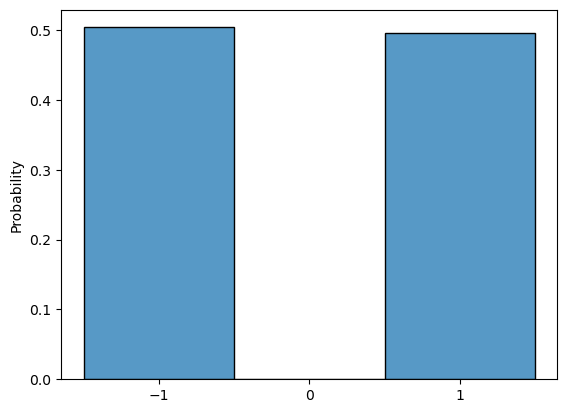

In [45]:
list_random_1_random_2 = []
for i in tqdm(range(1000)):
    result = run_models_against_each_other(model_random_1, model_random_2, verbose=False)
    list_random_1_random_2.append(result[0])


sns.histplot(list_random_1_random_2, discrete=True, stat="probability", bins=[-1.5, -0.5, 0.5, 1.5])
plt.xticks([-1, 0, 1])

In [8]:
all_losses = []
for i in range(1000):
    loss = nn.CrossEntropyLoss()
    input = torch.randn(1, 9, requires_grad=True)
    target = torch.empty(1, dtype=torch.long).random_(9)
    output = loss(input, target)
    all_losses.append(output.item())
print(input, target, output)

tensor([[ 0.0865, -0.3751, -1.1655, -0.6335, -0.8037,  0.6002,  0.9251, -0.2508,
         -0.0668]], requires_grad=True) tensor([4]) tensor(3.0148, grad_fn=<NllLossBackward0>)


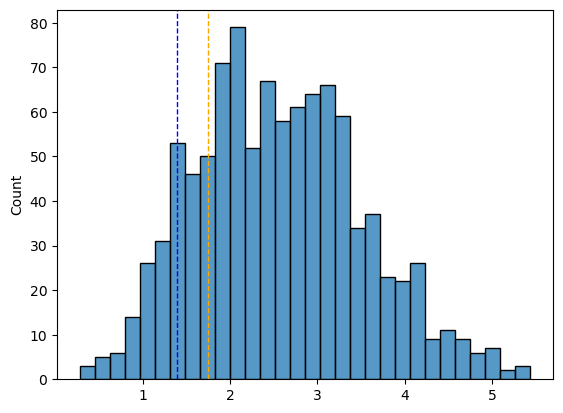

In [9]:
sns.histplot(all_losses, bins=30) # 1.3946, Val Loss: 1.7455
training_loss_final = 1.3946 # 1.659
validation_loss_final = 1.7455 # 2.085
plt.axvline(training_loss_final, color='blue', linestyle='dashed', linewidth=1, label='Training Loss')
plt.axvline(validation_loss_final, color='orange', linestyle='dashed', linewidth=1, label='Validation Loss')


100%|██████████| 1000/1000 [00:00<00:00, 3620.92it/s]


([<matplotlib.axis.XTick at 0x15c5c6b40>,
 [Text(-1, 0, '−1'), Text(0, 0, '0'), Text(1, 0, '1')])

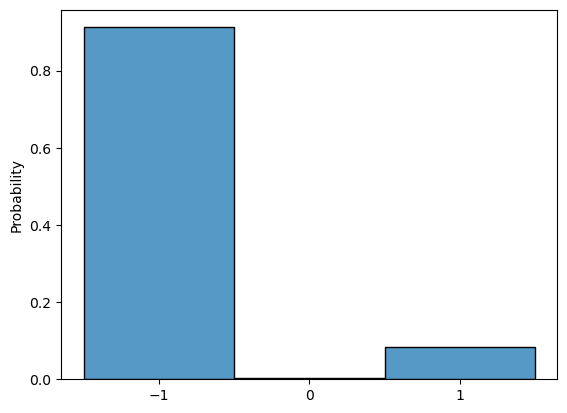

In [10]:
# play a game against the trained model
games_list_random_vs_minimax_nn = []
for i in tqdm(range(1000)):
    result = run_random_game_with_model(model_minimax, verbose=False)
    games_list_random_vs_minimax_nn.append(result[0])

sns.histplot(games_list_random_vs_minimax_nn, discrete=True, stat="probability", bins=[-1.5, -0.5, 0.5, 1.5])
plt.xticks([-1, 0, 1])

In [11]:
list_random_nn_vs_minimax_nn = []
for i in tqdm(range(1000)):
    result = run_models_against_each_other(model_random_1, model_minimax, verbose=False)
    list_random_nn_vs_minimax_nn.append(result[0])


sns.histplot(list_random_nn_vs_minimax_nn, discrete=True, stat="probability", bins=[-1.5, -0.5, 0.5, 1.5])
plt.xticks([-1, 0, 1])

  0%|          | 0/1000 [00:13<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
list_minimax_nn_vs_minimax = []
for i in tqdm(range(1000)):
    result = run_models_against_minimax(model_minimax, verbose=False)
    list_minimax_nn_vs_minimax.append(result[0])

sns.histplot(list_minimax_nn_vs_minimax, discrete=True, stat="probability", bins=[-1.5, -0.5, 0.5, 1.5])
plt.xticks([-1, 0, 1])
